In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
# Importing Libraries

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import astroalign as aa
import gc

from astropy.coordinates import SkyCoord
from astroquery.astrometry_net import AstrometryNet

/Users/alec/honours-env/.venv/lib/python3.11/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


In [4]:
def quickimdisplay(image, vmin=5, vmax=95, title=""):
    if vmin == vmax:
        vmin = np.percentile(image, 5)
        vmax = np.percentile(image, 95)
    vmin = np.percentile(image, vmin)
    vmax = np.percentile(image, vmax)
    plt.imshow(image, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    plt.xlabel("x pixels")
    plt.ylabel("y pixels")
    plt.title(title)
    s = len(image) / len(image[0])
    if s > 1:
        s = 1
    plt.colorbar(shrink=s, label="Counts")
    plt.show()

In [5]:
r_median = CCDData.read("r_median.fits")
b_median = CCDData.read("b_median.fits")
g_median = CCDData.read("g_median.fits")

xmin = 400
xmax = 1000
ymin = 400
ymax = 1200

r_median = r_median[ymin:ymax, xmin:xmax]
b_median = b_median[ymin:ymax, xmin:xmax]
g_median = g_median[ymin:ymax, xmin:xmax]

In [6]:
r_bkg = Background2D(r_median, 100)
b_bkg = Background2D(b_median, 100)
g_bkg = Background2D(g_median, 100)

r_processed = r_median.copy()
r_processed.data = r_median.data - r_bkg.background.value
r_processed.write("r_median.fits", overwrite=True)

b_processed = b_median.copy()
b_processed.data = b_median.data - b_bkg.background.value
b_processed.write("b_median.fits", overwrite=True)

g_processed = g_median.copy()
g_processed.data = g_median.data - g_bkg.background.value
g_processed.write("g_median.fits", overwrite=True)

In [7]:
# Adding WCS
ast = AstrometryNet()
ast.api_key = "hbdubkddgmftvaqo"


def add_wcs(filename):
    wcs_header = ast.solve_from_image(filename)
    with fits.open(filename, mode="update") as hdul:
        hdul[0].header.update(wcs_header)
        hdul.flush()


add_wcs("r_median.fits")
add_wcs("b_median.fits")
add_wcs("g_median.fits")

Determining background stats
Finding sources
Found 184 sources
 id     xcentroid      ...     mag           daofind_mag      
--- ------------------ ... ----------- -----------------------
116 135.98426955633812 ...  -12.574778     -6.1211431159277865
 57  591.7756853906194 ... -11.2043915      -4.876402243449175
104  399.6993642992818 ...  -11.023493      -4.637542964362458
 70 492.42887150595527 ...  -10.567989      -4.100755734135005
 35    404.66682410052 ...  -10.275344      -3.913875372858776
166 241.12400539550603 ... -10.0757265     -3.6431157145095088
109  39.59346578449388 ...   -9.972984      -3.514673980394034
175   279.079393259628 ...   -9.767702      -3.393888299195782
149 232.45338870958543 ...   -9.714203     -3.2848568209348397
152  479.0467745505612 ...    -9.69484     -3.3897280207746445
...                ... ...         ...                     ...
 83  487.1658693146414 ...  -6.1931634    -0.22525828257502734
163  598.2216221624183 ...   -6.142747    -0.1453803602

Determining background stats
Finding sources
Found 190 sources
 id     xcentroid          ycentroid      ...    mag          daofind_mag     
--- ------------------ ------------------ ... ---------- ---------------------
122  136.0541438405296  550.4812971725648 ... -12.634631    -6.539505307227359
 58  591.8154452200473   272.256062185113 ... -10.817106    -4.663237563075544
171 241.07017325016392  729.5885582332106 ... -10.170921    -4.125955997491058
108  399.7858615330917  511.1735318834303 ... -10.128338    -4.045047341153733
 70  492.4645359037195  335.6930155685892 ...  -9.813695   -3.6575597106801587
139 237.73713656723737  607.9360360377221 ...  -9.628402   -3.7074278788493626
182 279.07673108592064  758.3747551472231 ...  -9.625872    -3.616178455806157
154 232.47621978809929  650.6438243833667 ...  -9.558986   -3.4703705806122715
140 227.76899024402366  610.9506671784966 ...  -9.492472   -3.5515958916677874
 37 404.69726117409607 146.06633722540008 ...  -9.469622   -3.397583

Determining background stats
Finding sources
Found 250 sources
 id     xcentroid          ycentroid      ...    mag         daofind_mag     
--- ------------------ ------------------ ... ---------- --------------------
163 136.04476994357745  550.5365593102234 ... -12.670822   -6.978790364011516
 78  591.7946184752428 272.24565322085834 ... -10.917063   -5.192241714207006
145  399.7781635833517  511.2038214736766 ... -10.299618   -4.634766200710445
228 241.11377089582083  729.5826810699247 ... -10.152355   -4.415946096407811
 95 492.44034978580225 335.66726864533507 ...  -9.925865   -4.111956469901595
184   237.759784311296   607.912363979106 ...  -9.688362   -4.140252688327379
240  279.0990332298398  758.3035727696991 ...  -9.658731   -4.016745115192712
 47  404.6681924710105 146.08785843279097 ...  -9.641809  -3.9749489273880285
205 232.45942381100986   650.527349512647 ...   -9.62699   -3.875555999919615
185 227.73070110403785  610.9080408863598 ...  -9.556863   -4.006832087112039
.

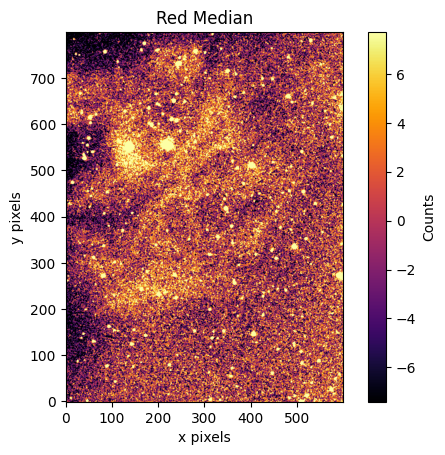

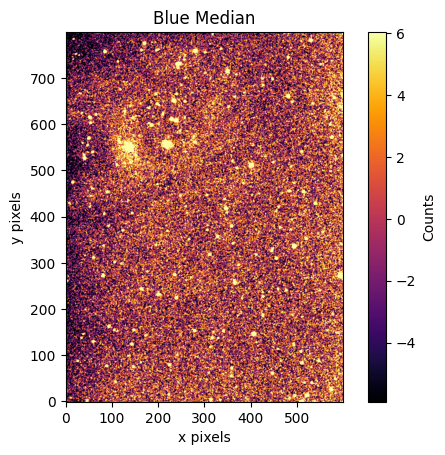

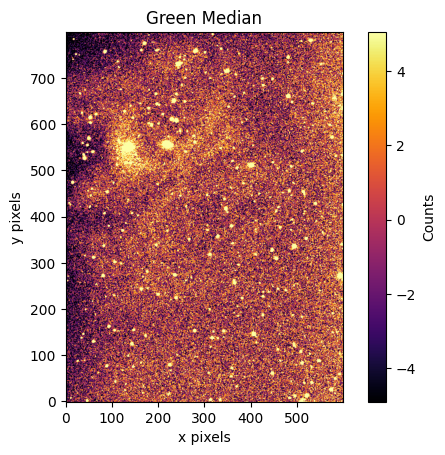

In [8]:
quickimdisplay(CCDData.read("r_median.fits").data, title="Red Median")
quickimdisplay(b_processed.data, title="Blue Median")
quickimdisplay(g_processed.data, title="Green Median")